**Author:** Gustavo Galvao

# Analysis of Educational Attainment as a Predictor for County-Level GDP

## Project Overview
This notebook investigates the relationship between human capital (measured by Bachelor's Degree attainment) and economic output (Real GDP) across Georgia's counties. The goal is to build a predictive model capable of estimating GDP trajectories based on educational shifts.

### The "Data Desert" Challenge (2003–2009)
A primary challenge of this study is the lack of annual education data prior to 2010. While county GDP data is available for the full 2003–2023 window, education data is anchored by the 2000 Decennial Census and the 2010 ACS estimates.

### Research Objectives
* **Baseline Validation:** Use the "Gold Standard" data (2010–2023) to establish a baseline correlation between Education and Total GDP.
* **Methodological Testing:** Compare three imputation methods (Linear Interpolation, Back-filling, and Baseline/Drop) to fill the 2003–2009 education gap.

### Modeling Strategy: Total GDP First
Due to heavy data suppression (NaNs) in industry-specific GDP columns many counties, this analysis prioritizes **Total Real GDP Growth** to maintain a consistent signal across all 159 counties.

## Notebook Structure
This notebook follows a modular workflow separated into 4 main chapters:

1.  **Data Ingestion & Cleaning:** Load TerraTrends dataset and filter for relevant predictors and years.
2. **Exploratory Data Analysis (EDA):**
    * Lagged Correlation Analysis ($t$ through $t-5$) to find the economic "reaction time."
    * Analyzing if change in education correlates better with GDP increase in opposition to pure higher education attainment percentage
3. **Imputation Experiment:**
    * **Dataset A:** Linear Interpolation (Steady growth assumption).
    * **Dataset B:** Back-filling (Stationary assumption).
    * **Dataset C:** Baseline (Excluding education metrics entirely).
4. **Model Benchmarking:** Comparing Mean Absolute Error (MAE) and $R^2$ across datasets and models to evaluate feature viability.

## Tech Stack
* **Language:** Python 3.10+.
* **Libraries:** `pandas`, `scikit-learn`, `seaborn`.
* **Data Sources:** IPUMS NHGIS (Census/ACS), Bureau of Economic Analysis (BEA).


# Data Ingestion and Cleaning

## Data Source and Loading

The notebook first begins by loading the TerraTrends updated data set (which now includes all population estimates from all counties from 2003 to 2023) which can be found in the [GitHub repository containing this notebook](https://github.com/Gustavo-Galvao-e-Silva/TerraTrends). This data set contains many columns, but we will focus on one single feature and a simplified predictor:
   * **Bachelor_Degree_or_Higher_Pct (predictor):** measures the percentage of adults aged 25+ who have at least a Bachelor's degree
   * **Percent_Change_Real_GDP (target):** measures the real GDP year-over-year

## Data Selection, Cleaning, and Temporal Filtering

To ensure a high "signal-to-noise" ratio during the initial Exploratory Data Analysis (EDA), we prioritize the **"Gold Standard"** period (2010–2023). This window provides the most reliable annual education data, allowing us to establish a baseline correlation before attempting to impute values for the 2003–2009 "data desert." Lastly, as the data is normally distributed, we can remove some outliers to achieve more conclusive results.

## Preliminary Data Check

Before moving to the analysis, we perform a "health check" on the dataframe to identify missing values and confirm data types, and as seen, the output from df.describe() shows the correct number of rows and no null entries.

In [74]:
# Chapter 1: Data Ingestion & Cleaning
import os

import matplotlib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Configuration constants
INPUT_DATA_PATH = "../data/input"
INPUT_FILE_NAME = "merged_data.csv"
TARGET_YEARS = list(range(2010, 2024))
PREDICTOR_COLUMN = "Bachelor_Degree_or_Higher_Pct"
TARGET_COLUMN = "Percent_Change_Real_GDP"
POPULATION_COLUMN = "TOT_POP"
ID_COLUMNS = ["County", "Year"]
RELEVANT_COLUMNS = ID_COLUMNS + [TARGET_COLUMN] + [PREDICTOR_COLUMN] + [POPULATION_COLUMN]
MAX_LAG = 5

# Loading and filtering
georgia_county_dataset_path = os.path.join(INPUT_DATA_PATH, INPUT_FILE_NAME)
georgia_county_df = pd.read_csv(georgia_county_dataset_path)
education_gdp_df = georgia_county_df[georgia_county_df["Year"].isin(TARGET_YEARS)][RELEVANT_COLUMNS].sort_values(by=ID_COLUMNS)

# Display and health checks
# education_gdp_df.describe(include="all")

# Exploratory Data Analysis (EDA)

## Lagged Correlation Analysis

Now, we begin working on analyzing how strongly education correlates with year-over-year GDP growth across different time horizons.

In regional economics, the impact of human capital is rarely instantaneous. There is typically a "gestation period" between an individual obtaining a degree and that education manifesting as increased local productivity or innovation. To account for this, we conduct a Lagged Correlation Analysis, shifting our education data forward by 0 to 5 years (t through t−5).

### Objectives of this Analysis

* Identify the "Reaction Time": Determine the specific number of years it takes for shifts in educational attainment to show the strongest statistical link to GDP changes.
* Establish Signal Strength: Quantify the linear relationship (Pearson Correlation) to assess if education is a "leading indicator" or merely a coincidental one.

In [75]:
def create_lagged_education_df(df: pd.DataFrame, max_lag: int, county_column_name: str, education_column_name: str) -> pd.DataFrame:
    new_df = df.copy()
    for i in range(max_lag + 1):
        new_column_name = f"education_t-{i}" if i > 0 else f"education_t"
        new_df[new_column_name] = new_df.groupby(county_column_name)[education_column_name].shift(i)

    return new_df

def remove_outliers_iqr(df: pd.DataFrame, column: str, multiplier: float = 1.5) -> pd.Series:
    q_1 = df[column].quantile(0.25)
    q_3 = df[column].quantile(0.75)
    iqr = q_3 - q_1
    lower_bound = q_1 - multiplier * iqr
    upper_bound = q_3 + multiplier * iqr
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

def display_lagged_scatter_plots(df: pd.DataFrame, max_lag: int, gdp_column_name: str) -> None:
    n_plots = max_lag + 1
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(15, 5 * n_rows),
        sharex=False,
        sharey=True,
        dpi=150
    )

    axes_flat = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

    for i in range(n_plots):
        education_column_name = f"education_t-{i}" if i > 0 else "education_t"
        valid_df = df.dropna(subset=[education_column_name, gdp_column_name])

        sns.regplot(
            ax=axes_flat[i],
            data=valid_df,
            x=education_column_name,
            y=gdp_column_name,
            line_kws={"color": "red"},
            scatter_kws={"color": "blue"}
        )

        axes_flat[i].set_title(f"{i} Year Lagged Education Level-GDP Scatter Plot")
        axes_flat[i].set_xlabel(f"Bachelor's attainment percentage ({i} year lag)")
        axes_flat[i].set_ylabel("GDP change")

    for j in range(n_plots, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout()
    plt.show()

def calculate_education_gdp_correlation(df: pd.DataFrame, max_lag: int, gdp_column_name: str) -> list[tuple[float]]:
    correlations = []
    for i in range(max_lag + 1):
        education_column_name = f"education_t-{i}" if i > 0 else f"education_t"
        valid_df = df.dropna(subset=education_column_name)
        corr, p = pearsonr(valid_df[gdp_column_name], valid_df[education_column_name])
        correlations.append((p, corr))

    return correlations

def display_education_lags_correlation(correlations: list[tuple[float]], max_lag: int) -> None:
    lags = list(range(max_lag + 1))
    p_values = [corr[0] for corr in correlations]
    corr_values = [corr[1] for corr in correlations]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(lags, corr_values, marker='o', linestyle='--', color='teal')
    ax1.set_title("Pearson Correlation Strength by Lag Year")
    ax1.set_xlabel("Years Lagged")
    ax1.set_ylabel("Correlation Coefficient")
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

    ax2.plot(lags, p_values, marker='s', linestyle='--', color='coral')
    ax2.set_title("P-values by Lag Year")
    ax2.set_xlabel("Years Lagged")
    ax2.set_ylabel("P-value")
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0.05, color='red', linestyle=':', linewidth=1, label='Significance Level (α = 0.05)')
    ax2.legend()

    plt.tight_layout()
    plt.show()

### Lagged Education vs. GDP Change Scatter Plots

#### Plotting Methods and Goals:

Following the removal of extreme GDP volatility outliers via the IQR method, we evaluate the predictive strength of human capital across six temporal horizons. The scatter plots below visualize the annual Real GDP Percent Change in relation to the Bachelor's Degree Attainment Rate, lagged from 0 to 5 years.

The grid is organized chronologically (increasing from t to t−5) from left to right and top to bottom. This configuration allows us to observe:

* Variance Sensitivity: Whether a specific time lag results in a "tighter" clustering of data points, indicating a more stable relationship.
* Trend-line Elasticity: Whether the slope of the regression line steepens at specific lags, revealing the "gestation period" or response-time required for educational shifts to manifest as measurable economic growth.

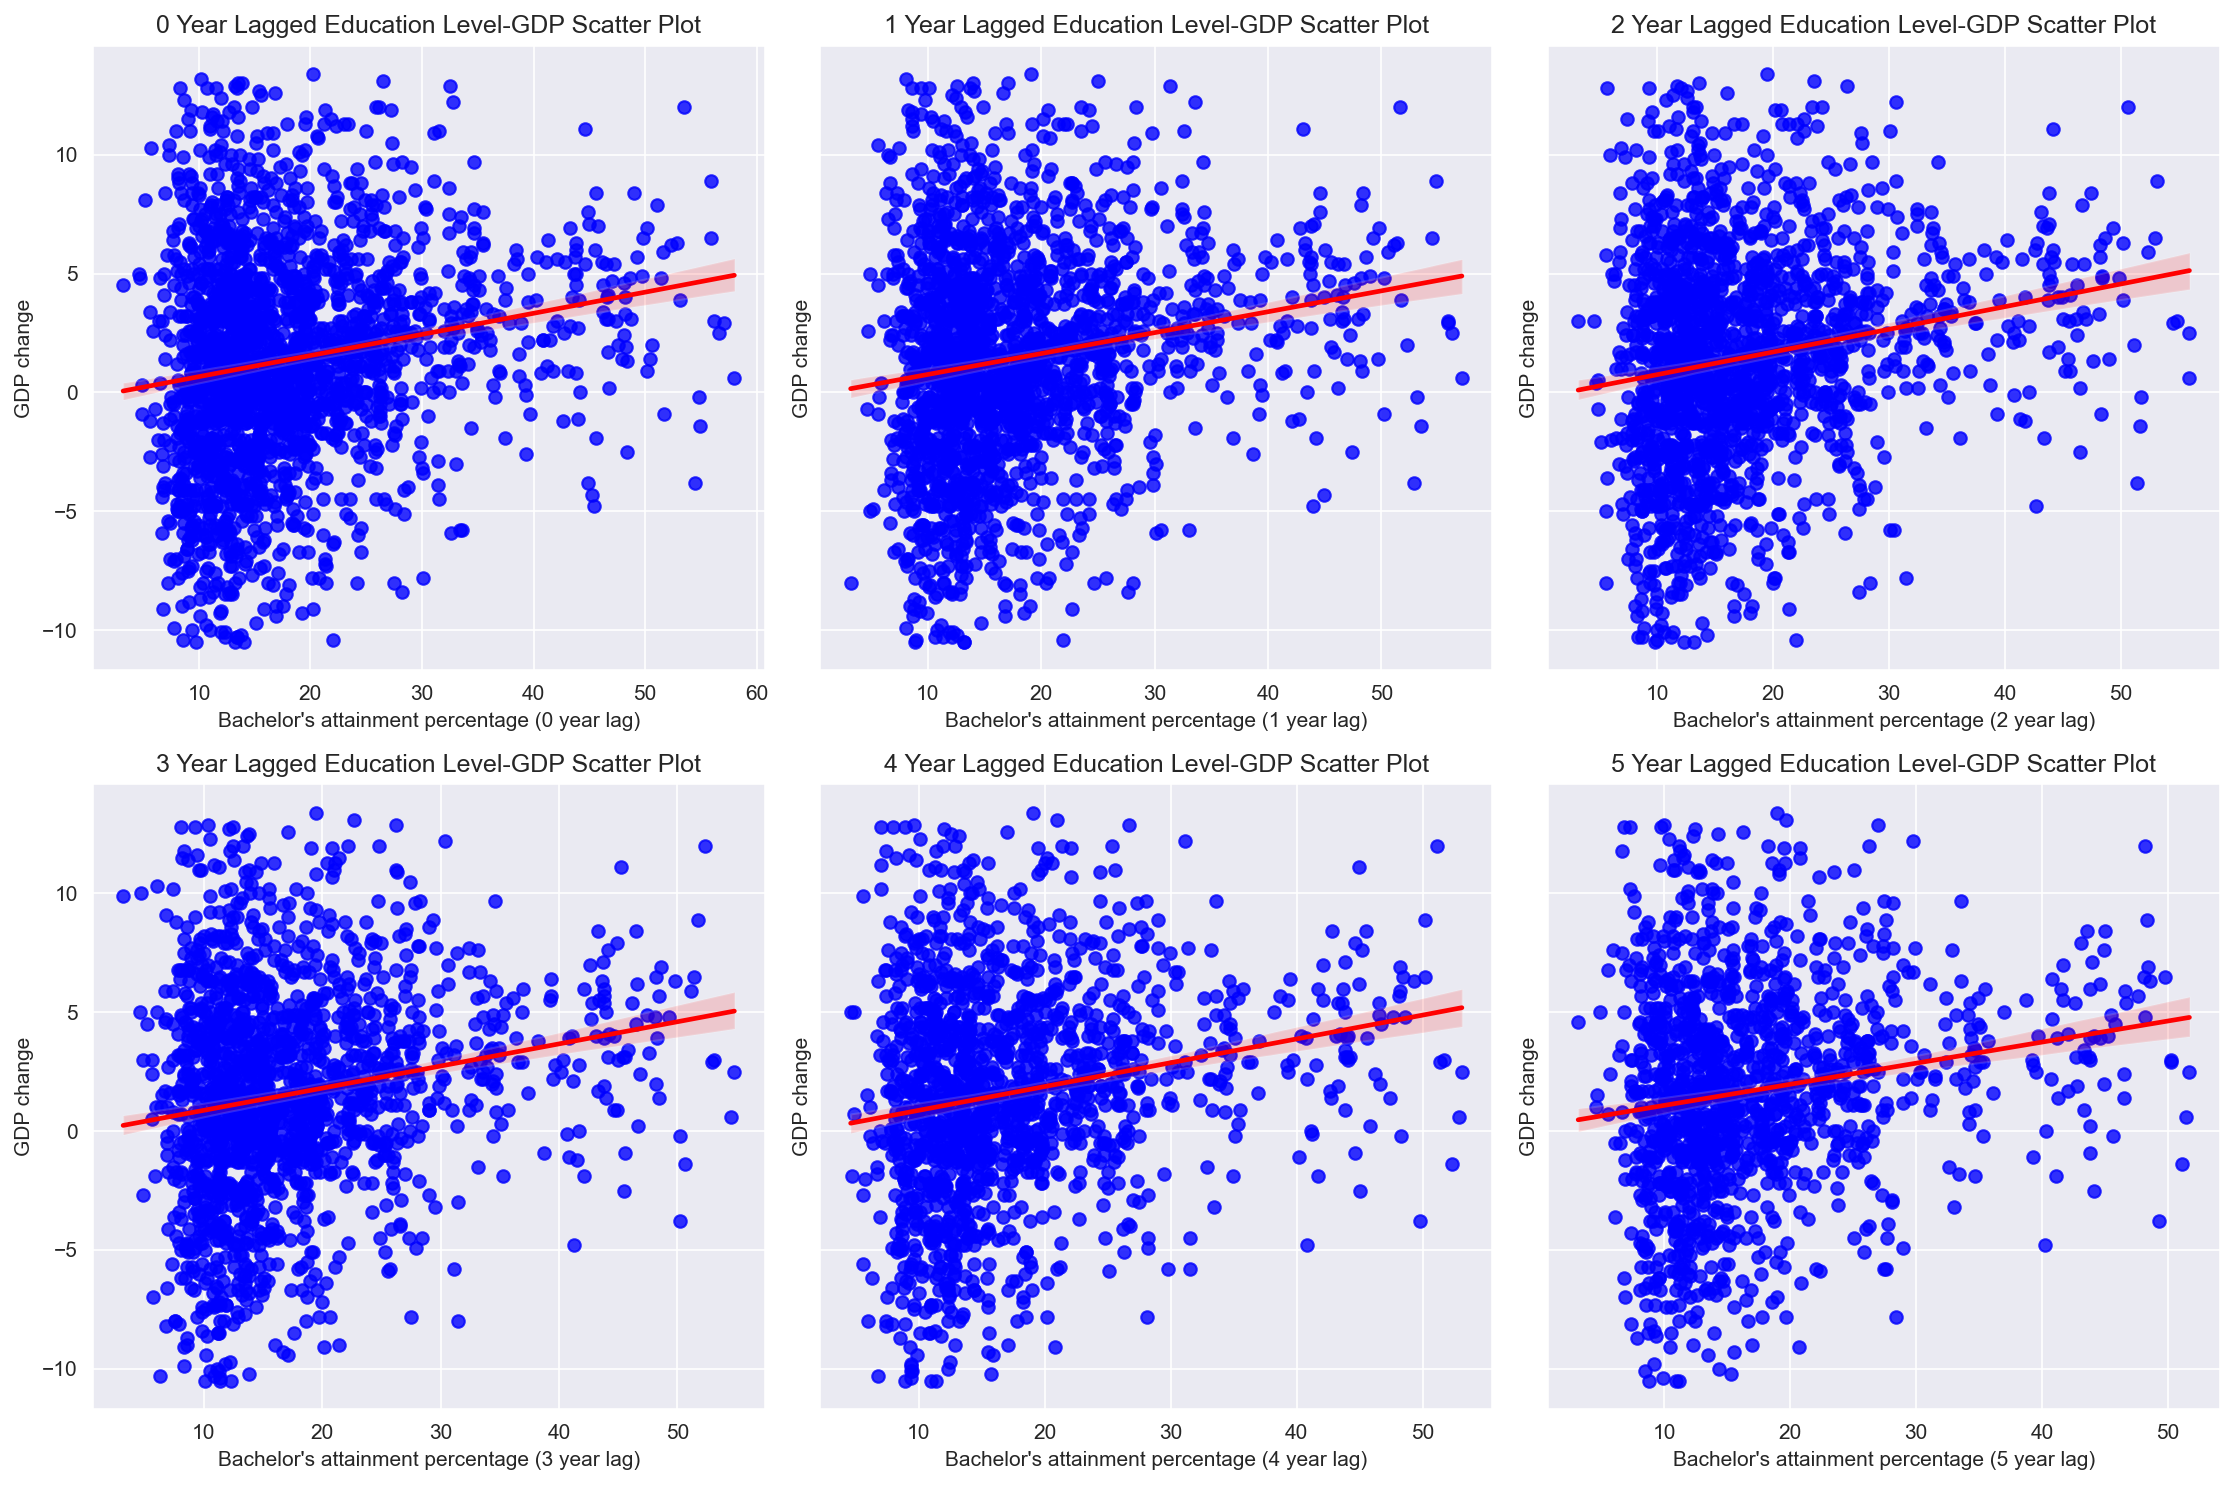

In [76]:
# Generate lagged education features
lagged_df = create_lagged_education_df(education_gdp_df, MAX_LAG, "County", PREDICTOR_COLUMN)
cleaned_lagged_df = remove_outliers_iqr(lagged_df, TARGET_COLUMN, 1.5)

# Display lagged education scatter plots
display_lagged_scatter_plots(cleaned_lagged_df, MAX_LAG, TARGET_COLUMN)


#### The Results:

The scatter plots provide an initial look into the predictive power of educational attainment on annual GDP growth. Several key observations emerge:

* Statistical Dispersion: The "cloud" of data points is highly dispersed across all 159 counties. This high variance suggests that while a relationship exists, it is subject to significant "noise" from other variables.
* Weak Linear Signal: The regression lines across all six plots maintain a consistently shallow, positive slope. With correlation coefficients (r) stagnating around 0.18, education level appears to be a "weak" linear predictor of annual growth.
* Temporal Invariance: Interestingly, increasing the lag from 0 to 5 years does not significantly "tighten" the scatter spread or dramatically improve the correlation. This suggests that the relationship between human capital and growth is structural (a permanent foundation) rather than dynamic (a specific trigger that sets off growth after X years). This result is very strongly supported by the next graph, which displays how the correlation between the two aforementioned parameters changes with increased lag.

#### Modelling Significance:

These results indicate that **a simple Linear Regression model will likely underperform. However, the consistent positive slope confirms that a signal does exist**. The next phase of this project will utilize non-linear algorithms (Random Forest and a simple Neural Network) to determine if these models can extract complex, high-dimensional patterns that simple linear correlations fail to capture.

### Correlation vs. Differing Lag Levels Graph

While the scatter plots provided a visual sense of the data's dispersion, the line graph below offers a precise mathematical summary of the relationship. By plotting the Pearson Correlation Coefficient (r) against each lag year (0–5), we can definitively see if a "peak" exists.

#### Goals of this Visualization:

* **Identify the Apex:** Pinpoint exactly which lag year provides the strongest signal for our model. In our findings, the "Level" of education shows a distinct, albeit modest, peak compared to the delta.
* **Assess Sensitivity:** Determine if the correlation is stable over time or if it decays rapidly as the lag increases. The high stability of the p-values for education levels (ranging from 10^-10 to 10^-17) suggests a very permanent structural relationship between the existing stock of human capital and growth.
* **Benchmark for Modeling:** This graph establishes the "limit" of linear predictability. Any performance gain achieved by our eventual Machine Learning models over these r values will represent the "Non-Linear Lift" provided by more complex algorithms.

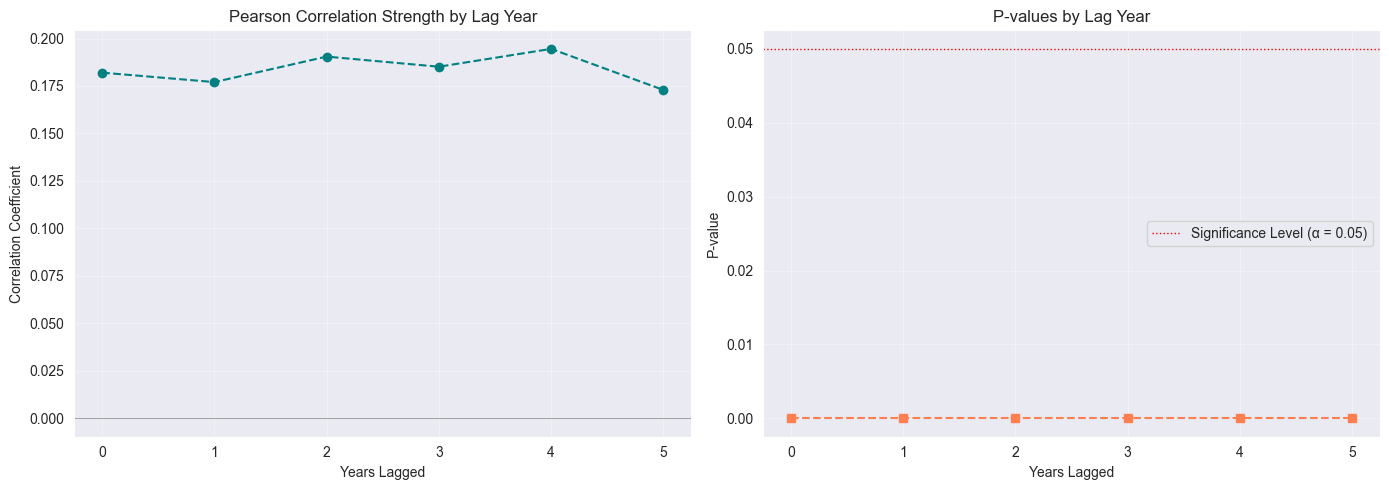

In [77]:
pearson_corrs = calculate_education_gdp_correlation(cleaned_lagged_df, lag, TARGET_COLUMN)
display_education_lags_correlation(pearson_corrs, lag)

#### The Results:

While the scatter plots showed significant dispersion, this line graph synthesizes those results to reveal the temporal behavior of our delta-on-delta predictor. Based on our analysis, we have the following insights:

* **Absence of a Temporal Peak:** Unlike the education levels, the Pearson correlation for education deltas shows no clear upward trend or "apex." The values fluctuate marginally between r = 0.009 and r = 0.021, eventually dipping to -0.026 at the 5-year lag. This suggests that annual changes in educational attainment do not have a cumulative linear "build-up" effect on GDP growth within this timeframe.
* **Persistent Statistical Insignificance:** The p-values for the delta-on-delta analysis are consistently high, ranging from 0.36 to 0.66. At no point does the lag reduce the p-value enough to approach the 0.05 significance threshold. This confirms that the year-over-year "flow" of new degrees is currently indistinguishable from statistical noise in predicting annual economic expansion.
* **Negligible Signal Strength:** With all r-values remaining below 0.03, the linear relationship is practically non-existent. This starkly contrasts with the "Level" analysis ($p < 10^{-16}$), reinforcing the conclusion that the total stock of human capital is an economically relevant predictor, while the annual rate of change is not.

#### Strategic Conclusion for Modeling:

The total lack of a significant signal in the Delta-on-Delta analysis indicates that raw annual changes in education should not be used as primary linear features. Instead, our modeling strategy will shift toward using **cumulative levels** or **smoothed rolling averages** to capture the impact of human capital. Since the delta fails to provide a leading indicator in a linear context, we will rely on Machine Learning models (such as Random Forest) to investigate if these deltas interact non-linearly with other variables—such as population density or industry specialization—to influence GDP.

## Education and GDP Delta-on-Delta Analysis

To further explore the possible relationship between education attainment and county GDP growth, we have performed a similar analysis correlating **GDP growth with education growth** (delta-on-delta). While economic theory often suggests that relative changes provide a cleaner signal by removing static county-level biases, our data shows that for Georgia counties, this form of correlation is exceptionally weak.

### Objectives of this Analysis#### The Results:

While the scatter plots showed significant dispersion, this line graph synthesizes those results to reveal the temporal "sweet spot" for our predictor. Based on our analysis, we have the following insights:

* **Identification of the 4-Year Peak:** The Pearson correlation for education levels doesn't stay flat; it trends upward as we increase the lag, peaking at 4 years with r = 0.1945. This suggests that the economic "return on education" in Georgia counties may take roughly four years to fully circulate into measurable GDP growth.
* **The Delta-Level Divergence:** There is a stark contrast between the two metrics. While Education Level is highly significant (p < 0.0001), the Education Delta is statistically irrelevant across all lags, with p-values ranging from 0.36 to 0.66. This confirms that the *presence* of a skilled workforce is a stronger driver of growth than the *annual rate of change* in that workforce.
* **Sub-0.20 Correlation:** Even at its peak, the correlation remains below 0.20. This empirically proves that while educational attainment is a relevant factor, it is likely part of a much larger, multi-variable equation involving industry mix, infrastructure, and capital investment.

#### Strategic Conclusion for Modeling:

Because the highest signal-to-noise ratio occurs at the 4-year lag for education levels, this specific feature will be prioritized in our feature engineering phase. The insignificance of the Delta-on-Delta results suggests that we should rely on "Level" features to capture the economic potential of a county. The presence of a clear peak justifies moving beyond simple correlation and into Machine Learning, where we can combine this 4-year lagged signal with other predictors to improve accuracy.

## Education and GDP Delta-on-Delta Analysis

To further explore the possible relationship between education attainment and county GDP growth, we will now do a similar analysis, but instead **correlating GDP growth with education growth** (delta-on-delta). Many variables, especially complex economic ones, relate better to each other when their relative changes are analyzed instead of their level; thus, it is important we analyze if these two variables hold this form of correlation, and in what delta timespan is it strongest.

### Objectives of this Analysis

* **Establish Signal Strength:** Quantify the linear relationship (Pearson Correlation) to assess if education delta is a "leading indicator" or merely a coincidental one. Our current results (r ≈ 0.01) suggest a very weak linear signal for short-term changes.
* **Assess Statistical Significance:** Determine if the changes are meaningful. With p-values as high as 0.665, we currently cannot reject the null hypothesis that there is no linear relationship between annual education deltas and GDP growth.
* **Examine Temporal Lags:** Identify if the "flow" of new degrees requires several years to manifest in the "delta" of GDP. Our results indicate that even with lagging, the year-over-year change remains an inconsistent predictor.

In [78]:
def create_lagged_delta_df(df: pd.DataFrame, max_lag: int, county_column_name: str, education_column_name: str) -> pd.DataFrame:
    new_df = df.copy()
    new_df['base_delta'] = new_df.groupby(county_column_name)[education_column_name].diff()

    for i in range(max_lag + 1):
        new_column_name = f"edu_delta_t-{i}"
        new_df[new_column_name] = new_df.groupby(county_column_name)['base_delta'].shift(i)

    return new_df

def display_lagged_delta_scatter_plots(df: pd.DataFrame, max_lag: int, gdp_column_name: str) -> None:
    n_plots = max_lag + 1
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(15, 5 * n_rows),
        sharex=False,
        sharey=False,
        dpi=150
    )

    axes_flat = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

    for i in range(n_plots):
        delta_column_name = f"edu_delta_t-{i}"
        valid_df = df.dropna(subset=[delta_column_name, gdp_column_name])

        if not valid_df.empty:
            sns.regplot(
                ax=axes_flat[i],
                data=valid_df,
                x=delta_column_name,
                y=gdp_column_name,
                line_kws={"color": "red"},
                scatter_kws={"color": "blue", "alpha": 0.5}
            )

            axes_flat[i].set_title(f"{i} Year Lagged Delta Education vs GDP")
            axes_flat[i].set_xlabel(f"Delta Bachelor's % ({i} year lag)")
            axes_flat[i].set_ylabel("GDP Variable")

    for j in range(n_plots, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout()
    plt.show()

def calculate_delta_gdp_correlation(df: pd.DataFrame, max_lag: int, gdp_column_name: str) -> list[tuple[float, float]]:
    correlations = []
    for i in range(max_lag + 1):
        delta_column_name = f"edu_delta_t-{i}"
        valid_df = df[[delta_column_name, gdp_column_name]].dropna()

        if len(valid_df) > 1:
            corr, p = pearsonr(valid_df[gdp_column_name], valid_df[delta_column_name])
            correlations.append((p, corr))
        else:
            correlations.append((np.nan, np.nan))

    return correlations

def display_delta_lags_correlation(correlations: list[tuple[float, float]], max_lag: int) -> None:
    lags = list(range(max_lag + 1))
    p_values = [corr[0] for corr in correlations]
    corr_values = [corr[1] for corr in correlations]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    ax1.plot(lags, corr_values, marker='o', linestyle='--', color='teal')
    ax1.set_title("Pearson Correlation Strength (Delta Education vs GDP)")
    ax1.set_xlabel("Years Lagged")
    ax1.set_ylabel("Correlation Coefficient (r)")
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

    ax2.plot(lags, p_values, marker='s', linestyle='--', color='coral')
    ax2.set_title("P-values by Lag Year")
    ax2.set_xlabel("Years Lagged")
    ax2.set_ylabel("P-value")
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0.05, color='red', linestyle=':', linewidth=1.5, label='Significance Level (α = 0.05)')
    ax2.legend()

    plt.tight_layout()
    plt.show()

### Education Change vs. GDP Change Scatter Plots

#### Plotting Methods and Goals:

We again remove extreme GDP volatility outliers via the IQR method and evaluate the strength of the correlation between the yearly change in GDP and the change in education attainment level. This is shown in the scatter plots below, correlating the change in GDP with the lagged annual change (delta) in the percentage of the population with a Bachelor's degree or higher.

The resulting visualization aims to determine if incremental improvements in the local talent pool serve as a statistically significant predictor for economic expansion.

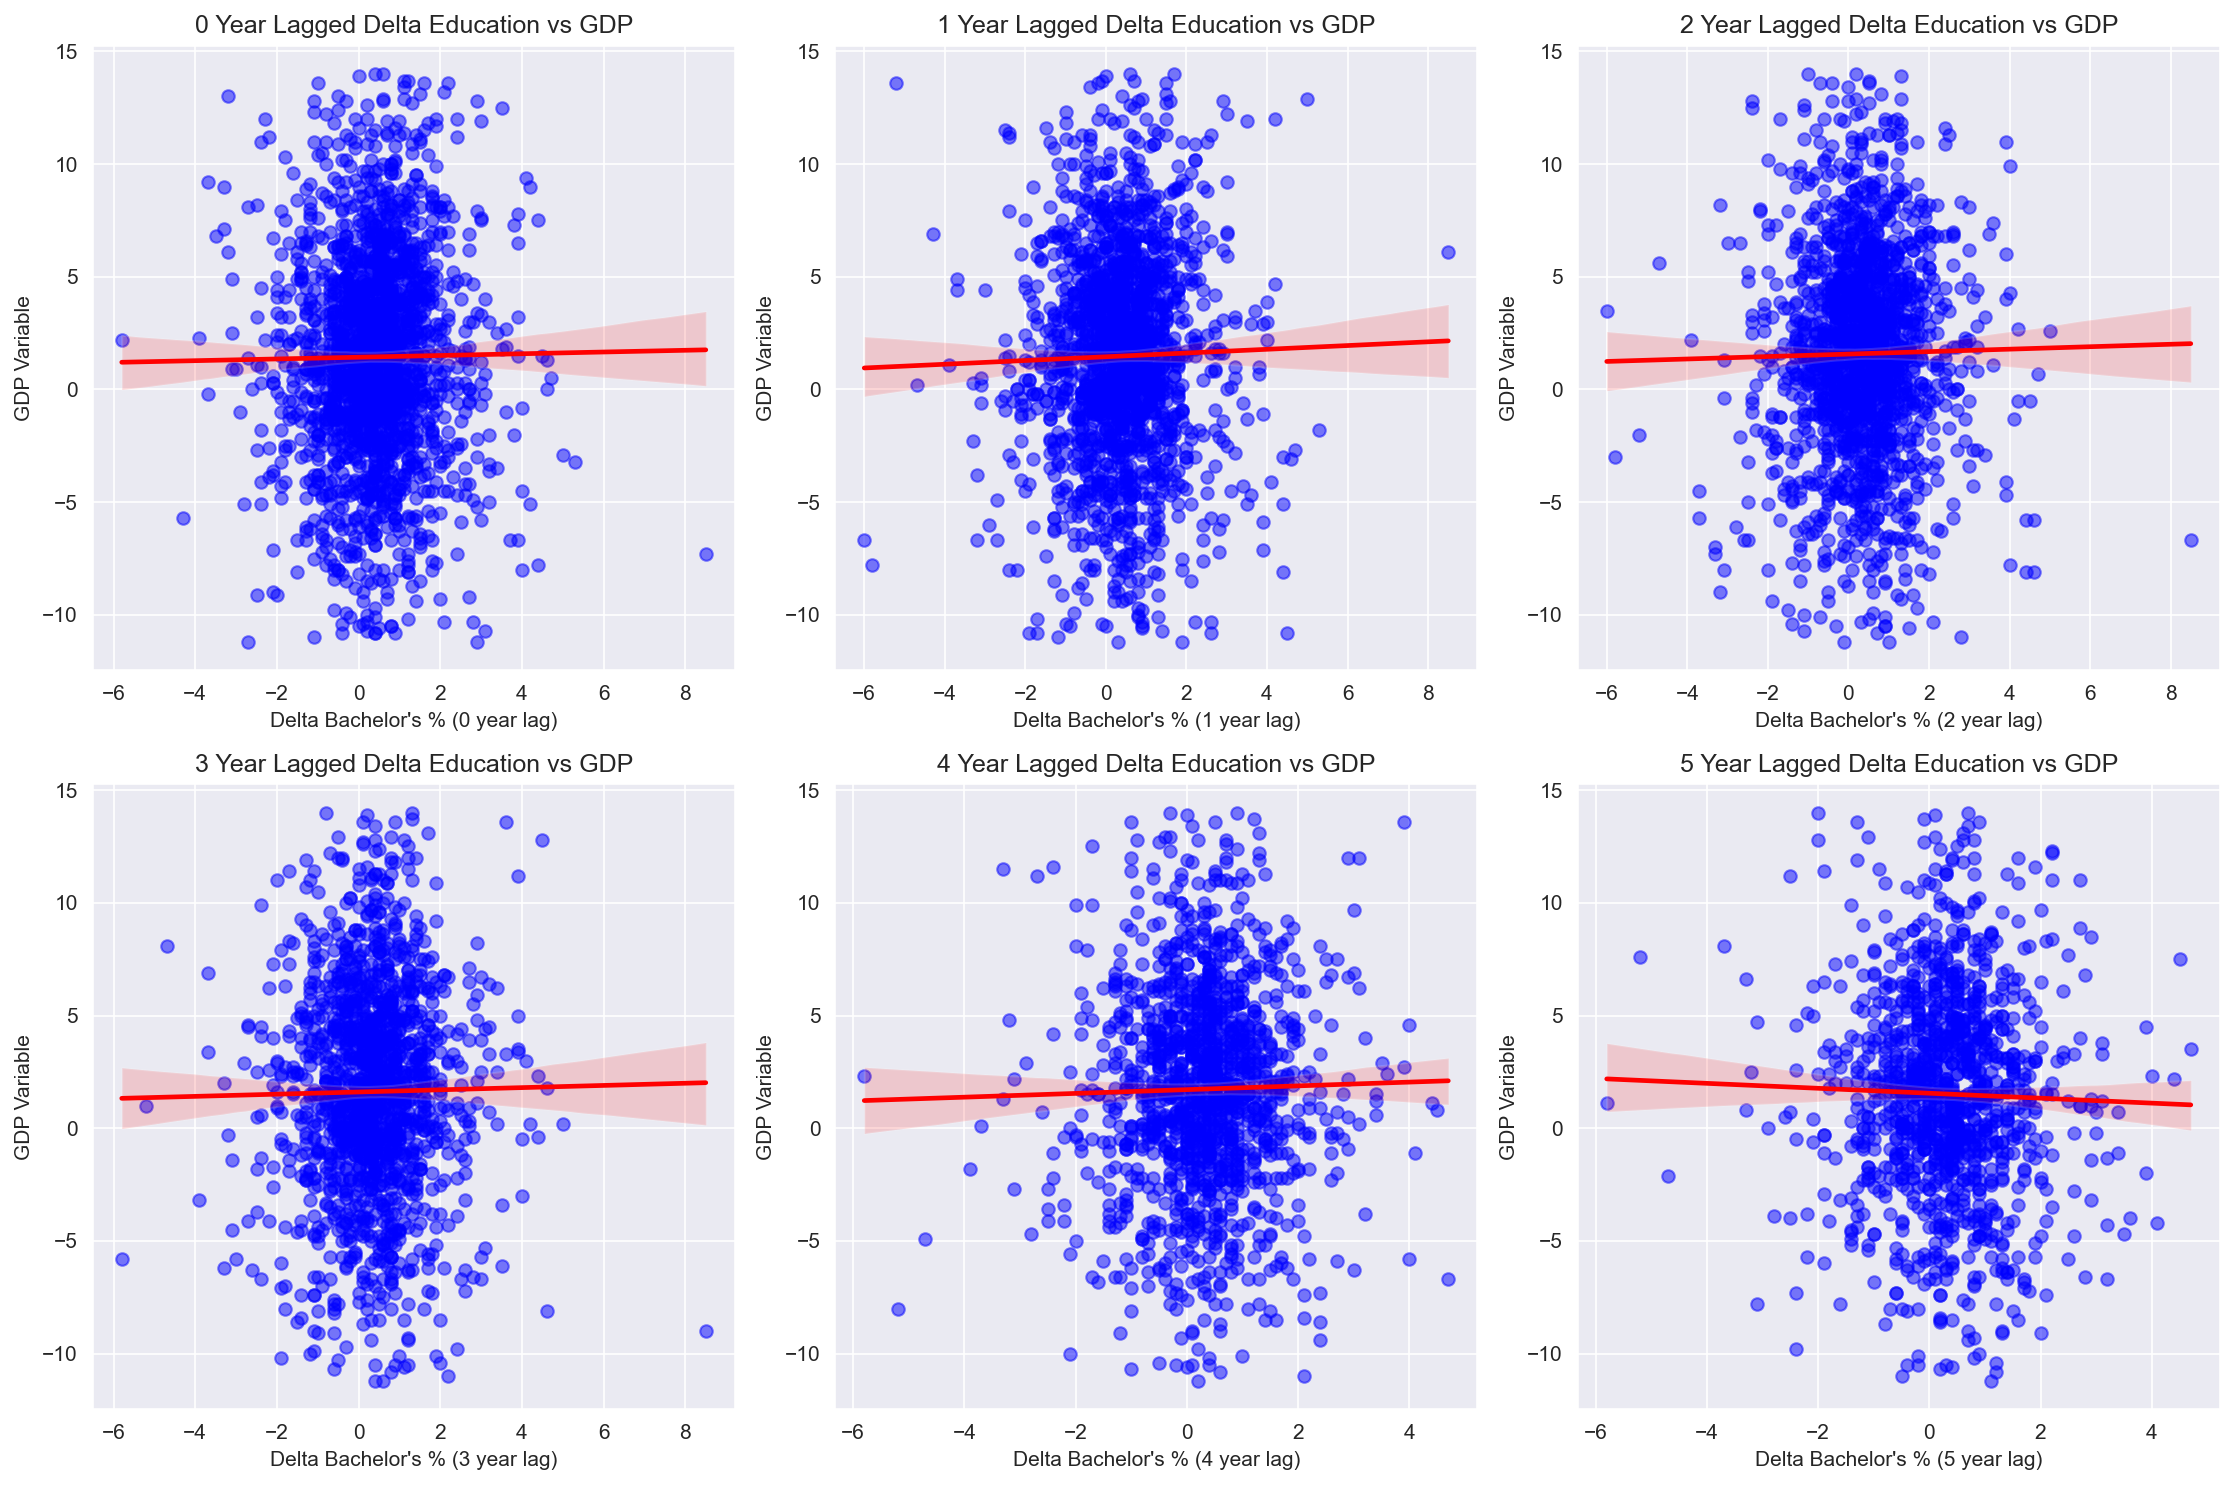

In [79]:
education_delta_df = create_lagged_delta_df(georgia_county_df, MAX_LAG, "County", PREDICTOR_COLUMN)

cleaned_delta_df = remove_outliers_iqr(education_delta_df, TARGET_COLUMN, 1.5)
display_lagged_delta_scatter_plots(cleaned_delta_df, MAX_LAG, TARGET_COLUMN)

#### The Results:

While the scatter plots showed significant dispersion, this line graph synthesizes those results to reveal the temporal behavior of our delta-on-delta predictor. Based on our analysis, we have the following insights:

* **Absence of a Temporal Peak:** Unlike the education levels, the Pearson correlation for education deltas shows no clear upward trend or "apex." The values fluctuate marginally between r = 0.009 and r = 0.021, eventually dipping to -0.026 at the 5-year lag. This suggests that annual changes in educational attainment do not have a cumulative linear "build-up" effect on GDP growth within this timeframe.
* **Persistent Statistical Insignificance:** The p-values for the delta-on-delta analysis are consistently high, ranging from 0.36 to 0.66. At no point does the lag reduce the p-value enough to approach the 0.05 significance threshold. This confirms that the year-over-year "flow" of new degrees is currently indistinguishable from statistical noise in predicting annual economic expansion.
* **Negligible Signal Strength:** With all r-values remaining below 0.03, the linear relationship is practically non-existent. This starkly contrasts with the "Level" analysis ($p < 10^{-16}$), reinforcing the conclusion that the total stock of human capital is an economically relevant predictor, while the annual rate of change is not.

#### Strategic Conclusion for Modeling:

The total lack of a significant signal in the Delta-on-Delta analysis indicates that raw annual changes in education should not be used as primary linear features. Instead, our modeling strategy will shift toward using **cumulative levels** or **smoothed rolling averages** to capture the impact of human capital. Since the delta fails to provide a leading indicator in a linear context, we will rely on Machine Learning models (such as Random Forest) to investigate if these deltas interact non-linearly with other variables to influence GDP.

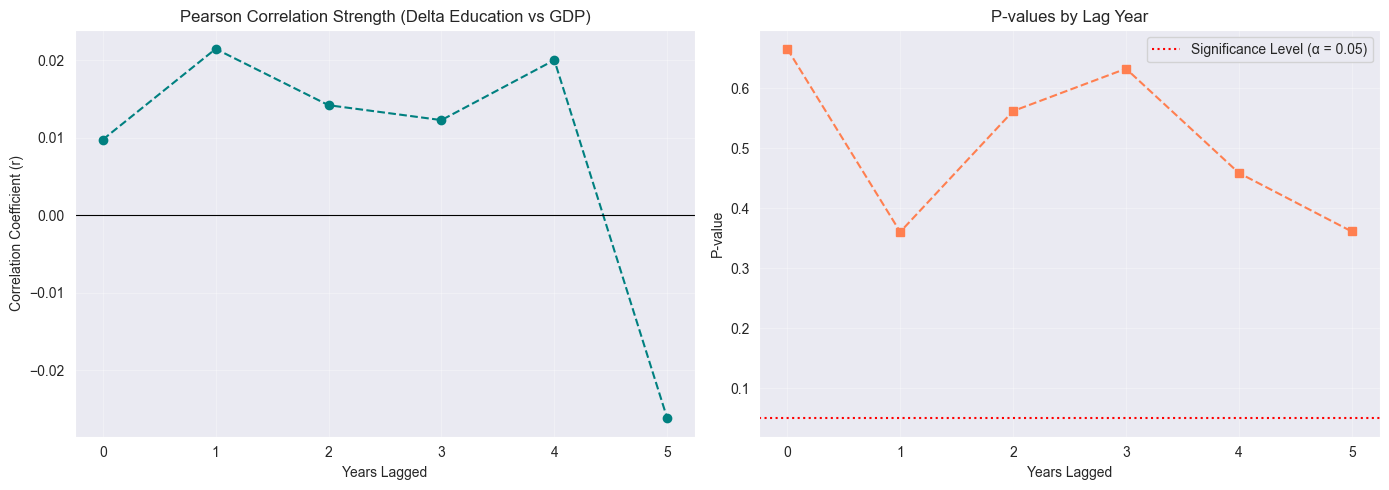

In [80]:
stats = calculate_delta_gdp_correlation(cleaned_delta_df, MAX_LAG, TARGET_COLUMN)
display_delta_lags_correlation(stats, MAX_LAG)